In [1]:
import pandas as pd 
import re 
import matplotlib.pyplot as plt

# <span style="color:#FFCC80"> Visualizing the outputs by loading the results txt file </span> </br>

In [3]:
# You need to first load the txt file and you need to know how that file is structured as it may vary depending on the optimization
# But generally if you use my optimizers at least they should al start with a #Iter and end ona line 

results_txt_path = r"E:\msc_data\sc_qsm\final_gauss_sims\feb_2026\chi_mapping_opt\snr_real\iter_fansi\wH_on\test2_VNS_ON.txt"

In [4]:
# We want to extrat the Iteration number, the RMSE and penalty (if there is one) and then all the parameters optimized
with open(results_txt_path, "r") as f:
    text = f.read()
# This is an example of a regex patter to extract from the txt
# In this pattern I know this comes from Fansi's opt with wH ON
pattern = re.compile(
    r"#Iter:\s*(?P<iter>\d+): Obj\. RMSE:\s*(?P<rmse>[\d.eE+-]+)"
    r"\s*\|\s*noise penalty:\s*(?P<penalty>[\d.eE+-]+).*?"
    r"Lamba:(?P<lambda>[\d.eE+-]+).*?"
    r"Gradient Consistency:\s*(?P<grad_consistency>[\d.eE+-]+).*?"
    r"Fidelity consistency:\s*(?P<fidelity_consistency>[\d.eE+-]+).*?"
    r"Harmonic constraint:\s*(?P<harmonic_constraint>[\d.eE+-]+).*?"
    r"Harmonic consistency:\s*(?P<harmonic_consistency>[\d.eE+-]+).*?"
    r"GM RMSE:\s*(?P<gm_rmse>[\d.eE+-]+), WM RMSE:\s*(?P<wm_rmse>[\d.eE+-]+)",
    re.DOTALL
)

rows = []
for m in pattern.finditer(text):
    row = {k: float(v) for k, v in m.groupdict().items()}
    row["iter"] = int(row["iter"])
    rows.append(row)

df = pd.DataFrame(rows)

df["rmse_plus_penalty"] = df["rmse"] + df["penalty"]

display(df.head())

,iter,rmse,penalty,lambda,grad_consistency,fidelity_consistency,harmonic_constraint,harmonic_consistency,gm_rmse,wm_rmse,rmse_plus_penalty
0,0,0.132820,0.132720,0.0002,0.02,1.0,150.0,3.00,0.065888,0.066933,0.265540
1,2,0.060476,0.040074,0.0012,0.12,2.0,0.5,0.01,0.041650,0.018826,0.100550
2,18,0.059441,0.045402,0.0002,0.02,2.0,5000.0,100.00,0.038526,0.020915,0.104843
3,26,0.057289,0.041060,0.0022,0.22,2.0,1800.0,36.00,0.038555,0.018734,0.098349
4,29,0.056929,0.040097,0.0032,0.32,2.0,2200.0,44.00,0.038779,0.018150,0.097026


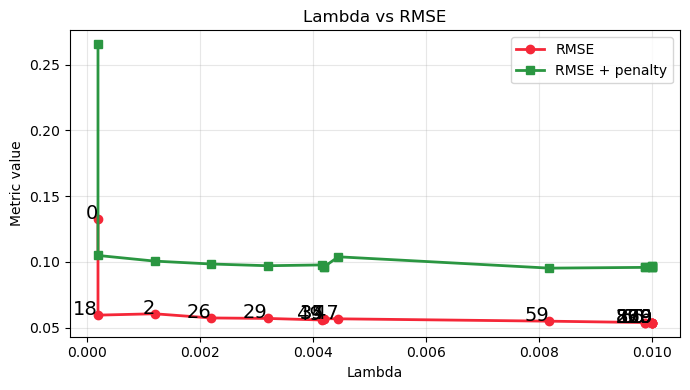

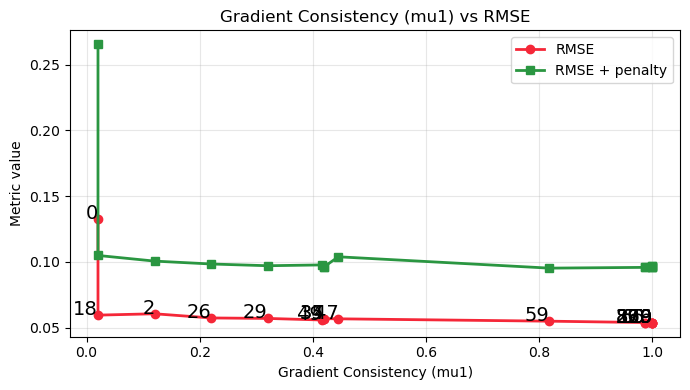

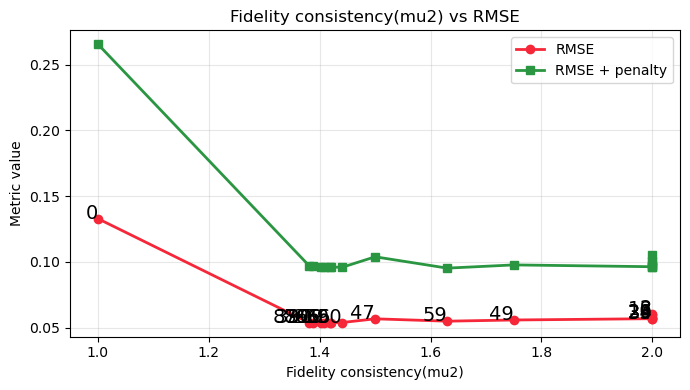

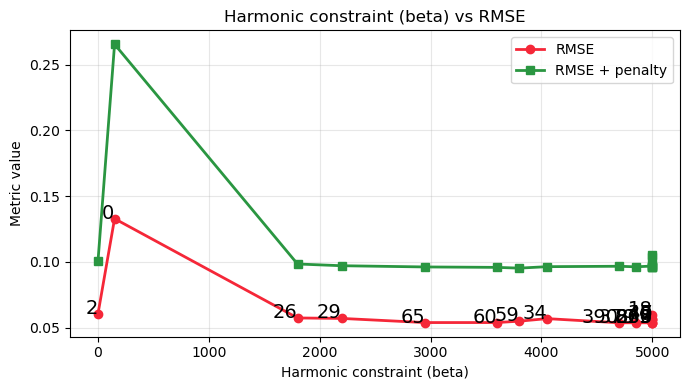

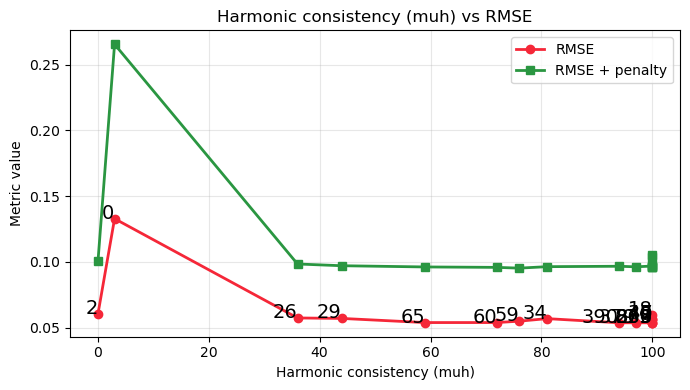

In [14]:
# Now we can plot
parameters = [
    "lambda",
    "grad_consistency",
    "fidelity_consistency",
    "harmonic_constraint",
    "harmonic_consistency",
]
# Change name of parameters just for plotting

parameters_plot = [
    "Lambda",
    "Gradient Consistency (mu1)",
    "Fidelity consistency(mu2)",
    "Harmonic constraint (beta)",
    "Harmonic consistency (muh)"
]

for param, param_plot in zip(parameters, parameters_plot):

    # sort values for smooth curves
    subdf = df.sort_values(param)

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.plot(
        subdf[param],
        subdf["rmse"],
        marker='o',
        linewidth=2,
        label="RMSE",
        color="#F52738"
    )

    ax.plot(
        subdf[param],
        subdf["rmse_plus_penalty"],
        marker='s',
        linewidth=2,
        label="RMSE + penalty",
        color="#2A9641"
    )

    for i, row in subdf.iterrows():
        ax.text(
            row[param],
            row["rmse"],
            str(int(row["iter"])),
            fontsize=14,
            ha='right',
        )

    ax.set_xlabel(param_plot)
    ax.set_ylabel("Metric value")
    ax.set_title(f"{param_plot} vs RMSE")

    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()